# Assignment 1: Hyperparameter Tuning

**Name:** *Elias Hawkins & Davin Matias*

# Part A: Restate Your Baseline

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

#### A1. Bring over Part 3 Multiclass model and results from Lab 1

In [ ]:
def plot_history(history, title, show_accuracy=False):
    if show_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(history.history["loss"], label="Training Loss")
        axes[0].plot(history.history["val_loss"], label="Validation Loss")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
        axes[0].set_title(title + " -- Loss")

        axes[1].plot(history.history["accuracy"], label="Training Accuracy")
        axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
        axes[1].set_title(title + " -- Accuracy")
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(6, 4))
        plt.plot(history.history["loss"], label="Training Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss (MSE, scaled)"); plt.title(title); plt.legend()
        plt.show()

In [ ]:
wine = fetch_openml(name="wine-quality-red", version=1, as_frame=True, parser="auto")
df3 = wine.frame

print(df3.shape)
print(df3["class"].astype(int).value_counts().sort_index())

(1599, 12)
class
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [ ]:
# Bucket raw quality scores into 3 bands: low / medium / high
def bucket_quality(q):
    q = int(q)
    if q <= 5:
        return 0  # low
    elif q == 6:
        return 1  # medium
    else:
        return 2  # high

df3["quality_band"] = df3["class"].apply(bucket_quality)
print(df3["quality_band"].value_counts().sort_index())

quality_band
0    744
1    638
2    217
Name: count, dtype: int64


In [ ]:
X3 = df3.drop(columns=["class", "quality_band"]).values.astype(float)
y3 = df3["quality_band"].values.astype(int)

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

x3_scaler = StandardScaler()
X3_train_scaled = x3_scaler.fit_transform(X3_train)
X3_test_scaled = x3_scaler.transform(X3_test)

In [ ]:
n_classes = len(np.unique(y3))

# Create the classification model
model_multi = tf.keras.Sequential([
    tf.keras.layers.Dense(8, activation="relu", input_shape=(X3_train_scaled.shape[1],)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax")
])

model_multi.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


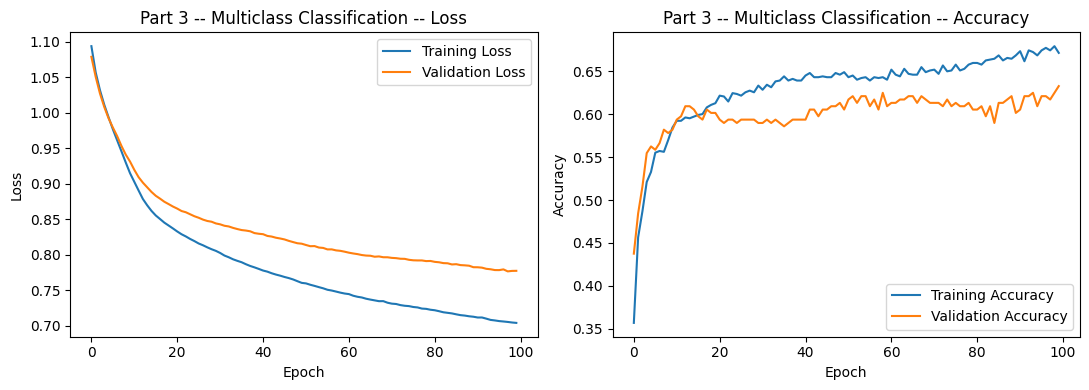

In [ ]:
history_multi = model_multi.fit(
    X3_train_scaled, y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(history_multi, "Part 3 -- Multiclass Classification", show_accuracy=True)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Part 3 -- Test Accuracy: 0.656


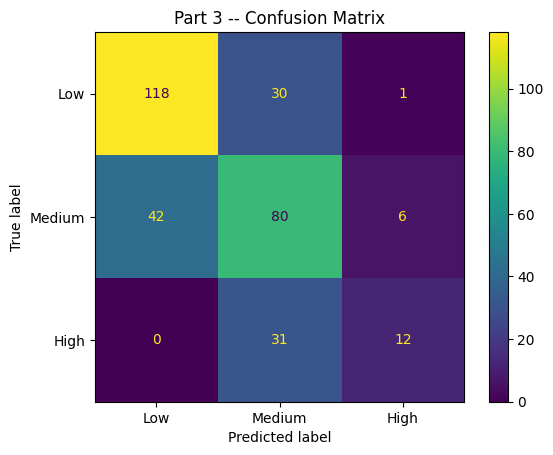

In [ ]:
multi_probs = model_multi.predict(X3_test_scaled)
multi_preds = np.argmax(multi_probs, axis=1)

acc_multi = accuracy_score(y3_test, multi_preds)
print(f"Part 3 -- Test Accuracy: {acc_multi:.3f}")

cm3 = confusion_matrix(y3_test, multi_preds)
ConfusionMatrixDisplay(cm3, display_labels=["Low", "Medium", "High"]).plot()
plt.title("Part 3 -- Confusion Matrix")
plt.show()

#### A2. Restate its original test accuracy, and describe what its training versus validation loss curve looked like. Did it show overfitting? Point to specific evidence from the curve (where the gap appeared, and what happened to validation loss as training continued).

**Answer**: The original test accuracy was/is 63.4%. The training versus validation loss curve determines a good fit. Both the traning and validation loss decrease while remaining at similar values. Then they plataeu and remain at a distance within a loss of 0.1 from each other. It did not show overfitting.

# Part B: Hyperparameter Tuning

#### B1. Using Keras Tuner, define a search space of at least 3 hyperparameters.

In [ ]:
# Import keras tuner
!pip install keras-tuner --quiet
import keras_tuner as kt

In [ ]:
# Define function
def build_model(hp):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(
            units=hp.Int("hidden1", min_value=16, max_value=128, step=16),
            activation="relu", input_shape=(n_features,)
        ),
        tf.keras.layers.Dense(
            units=hp.Int("hidden2", min_value=8, max_value=64, step=8),
            activation="relu"
        ),
        tf.keras.layers.Dense(n_classes, activation="softmax")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            hp.Choice("learning_rate", [0.001, 0.01, 0.1])
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

n_features = X3_train_scaled.shape[1]
n_classes = len(np.unique(y3_train))

#### B2. Run the search using training data only. Do not touch your test set during this step.

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X3, y3, test_size=0.2, random_state=42, stratify=y3)

In [ ]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=20,
    executions_per_trial=2,
    directory="tuner_results",
    project_name="wine_tuning",
    overwrite=True
)

tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    verbose=0
)

#### B3. Report the best configuration found and its validation score.

In [ ]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]

print("Best hyperparameters found:")
for name in best_hp.values:
    print(f"  {name}: {best_hp.values[name]}")

print(f"\nBest validation accuracy: {best_trial.score:.4f}")

Best hyperparameters found:
  hidden1: 112
  hidden2: 32
  learning_rate: 0.001

Best validation accuracy: 0.6953


#### B4. Train a final model using that configuration, and evaluate it once on your test set.

In [ ]:
best_model = tuner.hypermodel.build(best_hp)

final_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = best_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    callbacks=[final_early_stop],
    verbose=0
)

test_loss, test_acc = best_model.evaluate(X3_test, y3_test, verbose=0)

print(f"Final tuned model — test loss: {test_loss:.4f}, test accuracy: {test_acc:.4f}")

Final tuned model — test loss: 0.7780, test accuracy: 0.6438


#### B5. Compare this result to your original Lab 1 baseline. Did it improve, and by how much?

**Answer**: It did not improve, it actually got slightly worse.

# Part C: Addressing Overfitting

#### C1. Apply Dropout, Early Stopping, or both to your tuned model from Part B.

In [ ]:
def build_final_model(hp_values, dropout_rate=0.3):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(
            hp_values["hidden1"], activation="relu",
            input_shape=(X3_train_scaled.shape[1],)
        ),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(hp_values["hidden2"], activation="relu"),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(n_classes, activation="softmax")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp_values["learning_rate"]),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

final_model = build_final_model(best_hp.values, dropout_rate=0.3)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_final = final_model.fit(
    X3_train_scaled, y3_train,
    validation_split=0.2,
    epochs=200,
    callbacks=[early_stop],
    verbose=0
)

#### C2. Retrain, replot the training versus validation loss curve, and compare it directly to your original Lab 1 curve from Part A.

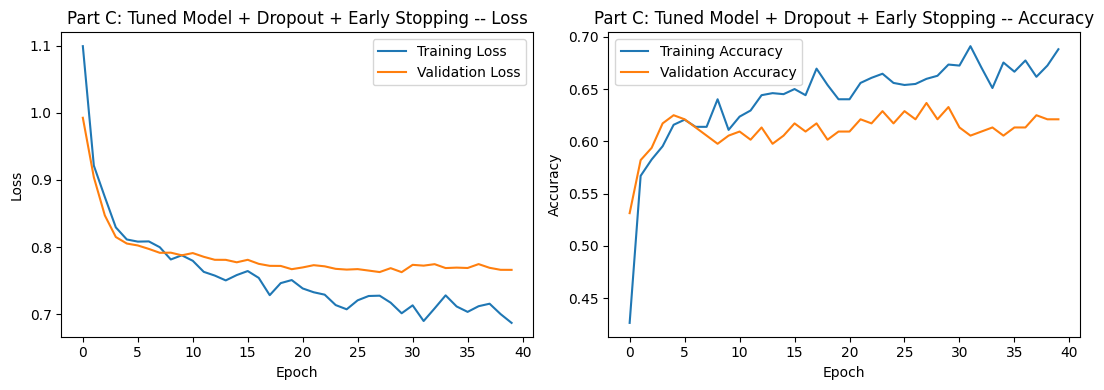

In [ ]:
plot_history(history_final, "Part C: Tuned Model + Dropout + Early Stopping", show_accuracy=True)

#### C3. Did the gap between training and validation loss shrink? Did validation loss stop rising, or improve further into training than before?

**Answer**: Yest, the gap actually shrunk. Validation loss improved further into the training than before. It plateaued a lot sooner than before.

#### C4. Report your final test accuracy and confusion matrix. Which classes are still being confused most often, and has that changed from Lab 1?

**Answer**: As seen below the medium class is still being confused most often, this has not changed from Lab 1.

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Part C -- Final Test Accuracy: 0.656


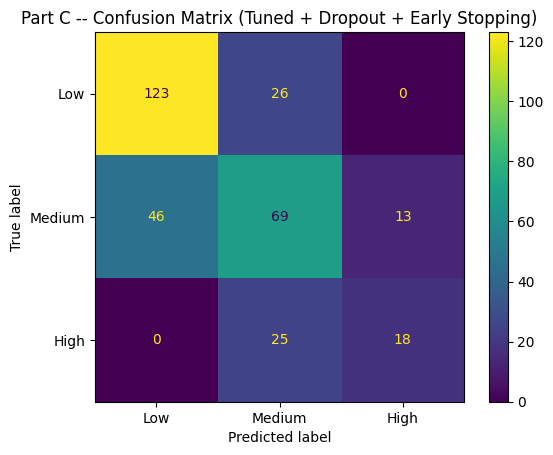

In [ ]:
final_probs = final_model.predict(X3_test_scaled)
final_preds = np.argmax(final_probs, axis=1)

acc_final = accuracy_score(y3_test, final_preds)
print(f"Part C -- Final Test Accuracy: {acc_final:.3f}")

cm_final = confusion_matrix(y3_test, final_preds)
ConfusionMatrixDisplay(cm_final, display_labels=["Low", "Medium", "High"]).plot()
plt.title("Part C -- Confusion Matrix (Tuned + Dropout + Early Stopping)")
plt.show()

# Part D: Reflection

#### D1. Why is it important that your test set was touched only once, at the very end?

**Answer**: The test set's purpose is to estimate how the model performs on data it has never influenced in any way. The moment you use test performance to make a decision, the test set stops being neutral and starts acting as training signal. Even though the model's weights never see the test data, your choices are now shaped by it, and choices are exactly what determine which model you end up with.

#### D2. What would have gone wrong if you had used your test set to pick the best hyperparameter configuration instead of a validation split?

**Answer**: If you ran 20 hyperparameter trials and picked whichever one scored highest on the test set, you're no longer selecting the model that generalizes best. With enough trials, some configuration will score well on the test set by chance alone, even if it isn't actually the best-generalizing model. Your reported test accuracy would then be optimistically biased.

#### D3. Did Dropout or Early Stopping meaningfully reduce the overfitting you saw in Lab 1? What evidence from your new loss curve supports your answer?

**Answer** It did, the new loss curve is a lot more plateaud and flat. The validation loss evened out much quicker than it did in Lab 1.

#### D4. If you had unlimited time and compute, what would you try next to improve this model further?

**Answer**: I would try a couple things including Search more hyperparameters, more thoroughly, add or engineer better features, and use cross-validation instead of one train/validation split, average results over several splits for a more reliable comparison between hyperparameter configs.